In [1]:
import pandas as pd

df = pd.read_csv(
    "/home/charis/Desktop/Projects/Anti-Money-Laundering-Transaction/SAML-D.csv"
)

df.head()


,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits
1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out
2,10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out
3,10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In
4,10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits


Summary of variables:

- Time the time where the transaction done. <br>

- Date the date where the tranasaction done. <br>

- Sender account the account who sends the the money. <br>

- Amount the amount of money that the sender sends. <br>

- Payment currency: the type of currency that the sender gave. <br>

- Received currency: the type of currency that sender gave. <br>

- Sender_bank_location: the country that sender sends. <br>

- Receiver_bank_location: the country of receiver 's account. <br>

- Payment_type: the the payment type. <br>

- Is_laundering: if the transaction is laundering (0 or 1). <br>

- Laundering_type: the type of laundering type.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9504852 entries, 0 to 9504851
Data columns (total 12 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   Time                    str    
 1   Date                    str    
 2   Sender_account          int64  
 3   Receiver_account        int64  
 4   Amount                  float64
 5   Payment_currency        str    
 6   Received_currency       str    
 7   Sender_bank_location    str    
 8   Receiver_bank_location  str    
 9   Payment_type            str    
 10  Is_laundering           int64  
 11  Laundering_type         str    
dtypes: float64(1), int64(3), str(8)
memory usage: 1.4 GB


# Feature Engineering

- Date should be datetime and not str.

- Payment_currency, Received_currency, Sender_bank_location, Receiver_bank_location, Payment_type, Laundering_type should be converted to category.

In [3]:
# converting to category
df['Payment_currency'] = df['Payment_currency'].astype('category')
df['Received_currency'] = df['Received_currency'].astype('category')
df['Sender_bank_location'] = df['Sender_bank_location'].astype('category')
df['Payment_type'] = df['Payment_type'].astype('category')
df['Laundering_type'] = df['Laundering_type'].astype('category')
df.dtypes[df.dtypes == 'category']


Payment_currency        category
Received_currency       category
Sender_bank_location    category
Payment_type            category
Laundering_type         category
dtype: object

In [4]:
# Convert time to datetime
df['Date'] = pd.to_datetime(df['Date'])

In [5]:
df.dtypes

Time                                 str
Date                      datetime64[us]
Sender_account                     int64
Receiver_account                   int64
Amount                           float64
Payment_currency                category
Received_currency               category
Sender_bank_location            category
Receiver_bank_location               str
Payment_type                    category
Is_laundering                      int64
Laundering_type                 category
dtype: object

In [6]:
df.head()

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits
1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out
2,10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out
3,10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In
4,10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits


In [7]:
df.isnull().sum()

Time                      0
Date                      0
Sender_account            0
Receiver_account          0
Amount                    0
Payment_currency          0
Received_currency         0
Sender_bank_location      0
Receiver_bank_location    0
Payment_type              0
Is_laundering             0
Laundering_type           0
dtype: int64

In [8]:
df.describe()

,Date,Sender_account,Receiver_account,Amount,Is_laundering
count,9504852,9.504852e+06,9.504852e+06,9.504852e+06,9.504852e+06
mean,2023-03-15 21:03:37.048722,5.006619e+09,5.006006e+09,8.762968e+03,1.038733e-03
min,2022-10-07 00:00:00,9.018000e+03,9.018000e+03,3.730000e+00,0.000000e+00
25%,2022-12-27 00:00:00,2.513133e+09,2.513219e+09,2.143688e+03,0.000000e+00
50%,2023-03-15 00:00:00,5.001017e+09,5.002572e+09,6.113720e+03,0.000000e+00
75%,2023-06-03 00:00:00,7.505051e+09,7.502397e+09,1.045846e+04,0.000000e+00
max,2023-08-23 00:00:00,9.999987e+09,9.999971e+09,1.261850e+07,1.000000e+00
std,NaN,2.885814e+09,2.884763e+09,2.561495e+04,3.221263e-02


# Univariate analysis

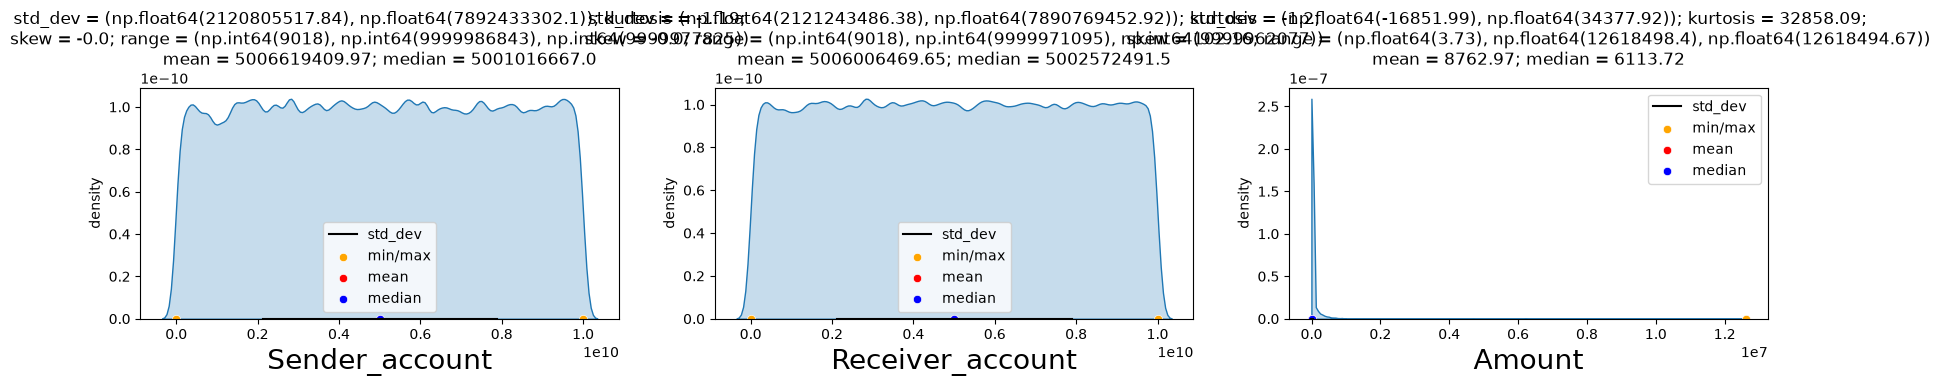

In [ ]:
# custom function for easy and efficient analysis of numerical univariate
import matplotlib.pyplot as plt 
import seaborn as sns 

def UVA_numeric(data, var_group):
  '''
  Univariate_Analysis_numeric
  takes a group of variables (INTEGER and FLOAT) and plot/print all the descriptives and properties along with KDE.

  Runs a loop: calculate all the descriptives of i(th) variable and plot/print it
  '''

  size = len(var_group)
  plt.figure(figsize = (7*size,3), dpi = 100)
  
  #looping for each variable
  for j,i in enumerate(var_group):
    
    # calculating descriptives of variable
    mini = data[i].min()
    maxi = data[i].max()
    ran = data[i].max()-data[i].min()
    mean = data[i].mean()
    median = data[i].median()
    st_dev = data[i].std()
    skew = data[i].skew()
    kurt = data[i].kurtosis()

    # calculating points of standard deviation
    points = mean-st_dev, mean+st_dev

    #Plotting the variable with every information
    plt.subplot(1,size,j+1)
    sns.kdeplot(data[i], fill = True)
    plt.plot(points, [0, 0], color='black', label="std_dev")
    
    sns.scatterplot(x=[mini, maxi], y=[0, 0], color='orange', label="min/max")
    sns.scatterplot(x=[mean], y=[0], color='red', label="mean")
    sns.scatterplot(x=[median], y=[0], color='blue', label="median")
    plt.xlabel('{}'.format(i), fontsize = 20)
    plt.ylabel('density')
    plt.title('std_dev = {}; kurtosis = {};\nskew = {}; range = {}\nmean = {}; median = {}'.format((round(points[0],2),round(points[1],2)),
                                                                                                   round(kurt,2),
                                                                                                   round(skew,2),
                                                                                                   (round(mini,2),round(maxi,2),round(ran,2)),
                                                                                                   round(mean,2),
                                                                                                   round(median,2)))
    
UVA_numeric(df,['Sender_account',	'Receiver_account', 'Amount'])

--- Variable: Payment_currency (n_uniques = 13) ---
Payment_currency
UK pounds          0.957331
Euro               0.012327
Turkish lira       0.002945
Swiss franc        0.002892
Dirham             0.002868
Pakistani rupee    0.002861
Naira              0.002856
US dollar          0.002742
Yen                0.002689
Moroccan dirham    0.002672
Mexican Peso       0.002615
Albanian lek       0.002607
Indian rupee       0.002594
Name: proportion, dtype: float64
----------------------------------------


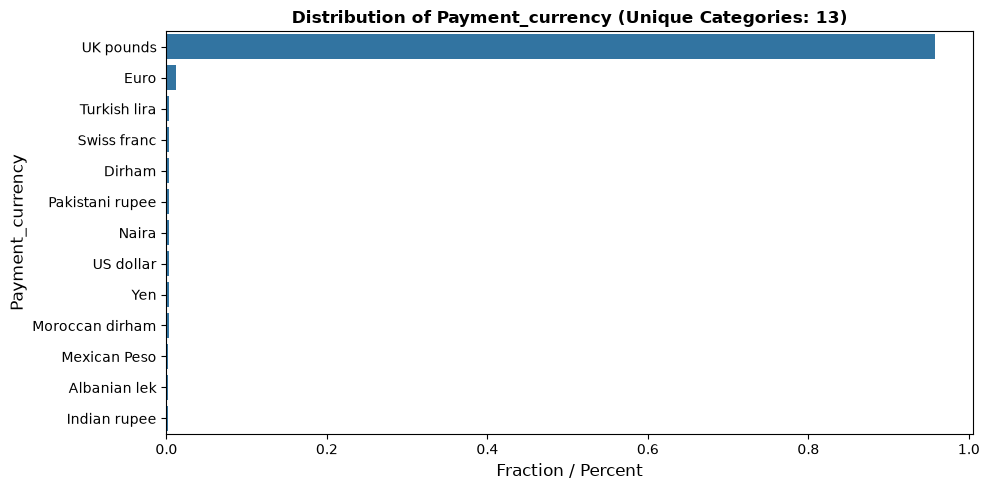

--- Variable: Received_currency (n_uniques = 13) ---
Received_currency
UK pounds          0.924123
Euro               0.024399
Pakistani rupee    0.004839
Yen                0.004820
Moroccan dirham    0.004813
Albanian lek       0.004812
Mexican Peso       0.004761
Naira              0.004739
Indian rupee       0.004604
US dollar          0.004594
Swiss franc        0.004517
Dirham             0.004503
Turkish lira       0.004476
Name: proportion, dtype: float64
----------------------------------------


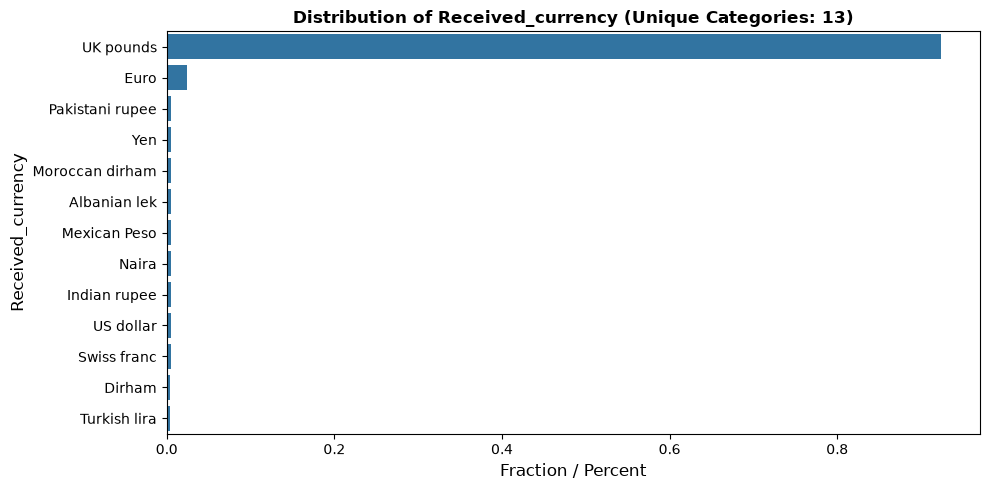

--- Variable: Sender_bank_location (n_uniques = 18) ---
Sender_bank_location
UK             0.966147
Turkey         0.002199
Switzerland    0.002157
Pakistan       0.002141
UAE            0.002113
Nigeria        0.002107
Spain          0.002040
Germany        0.002026
USA            0.002002
Italy          0.001988
France         0.001968
Japan          0.001943
Morocco        0.001940
Austria        0.001899
Mexico         0.001858
Albania        0.001857
India          0.001851
Netherlands    0.001764
Name: proportion, dtype: float64
----------------------------------------


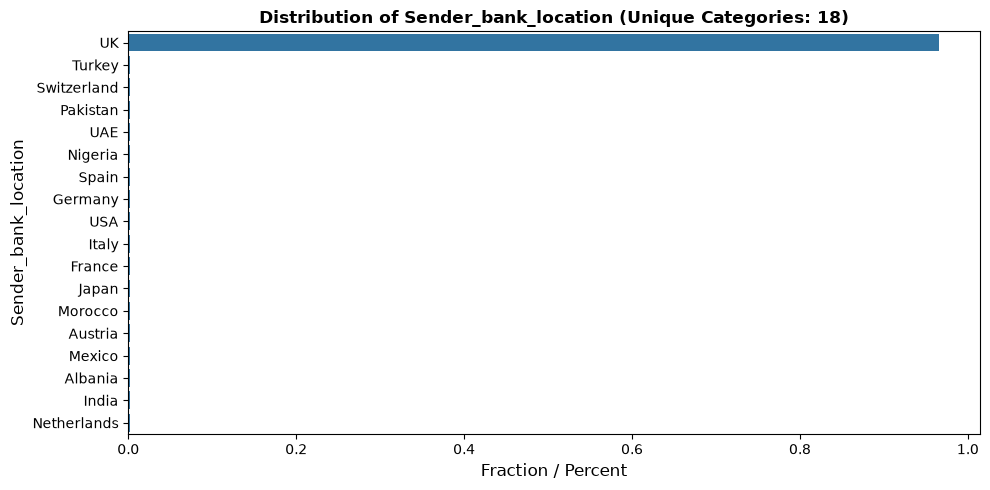

--- Variable: Receiver_bank_location (n_uniques = 18) ---
Receiver_bank_location
UK             0.932643
Pakistan       0.004101
Austria        0.004087
Albania        0.004080
Japan          0.004075
Morocco        0.004072
Germany        0.004055
France         0.004052
Mexico         0.004038
Nigeria        0.004027
Netherlands    0.003926
Spain          0.003923
India          0.003886
USA            0.003877
Italy          0.003842
Switzerland    0.003796
UAE            0.003777
Turkey         0.003744
Name: proportion, dtype: float64
----------------------------------------


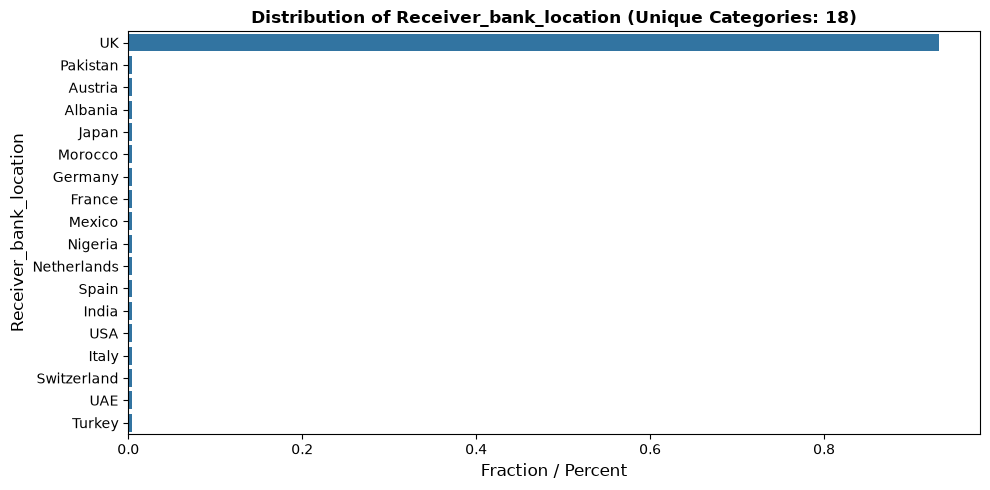

--- Variable: Payment_type (n_uniques = 7) ---
Payment_type
Credit card        0.211777
Debit card         0.211692
Cheque             0.211620
ACH                0.211345
Cross-border       0.098258
Cash Withdrawal    0.031613
Cash Deposit       0.023694
Name: proportion, dtype: float64
----------------------------------------


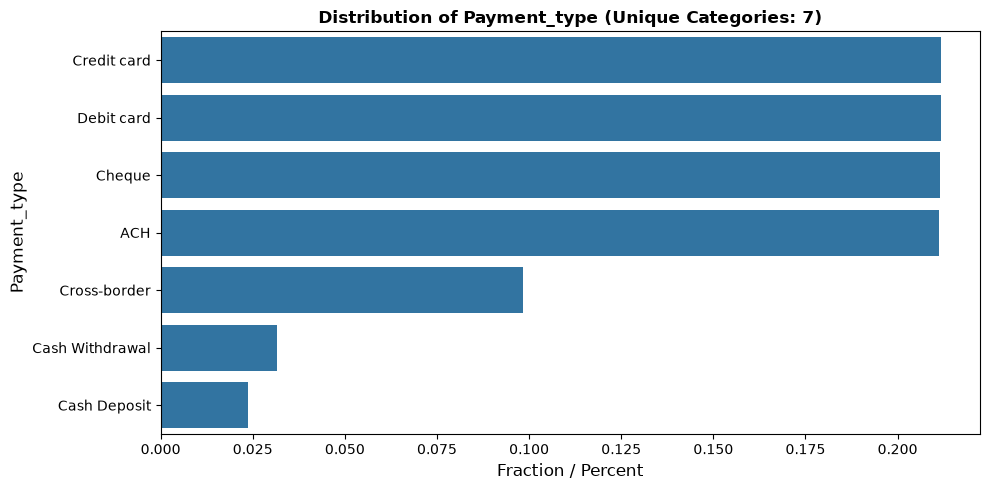

--- Variable: Is_laundering (n_uniques = 2) ---
Is_laundering
0    0.998961
1    0.001039
Name: proportion, dtype: float64
----------------------------------------


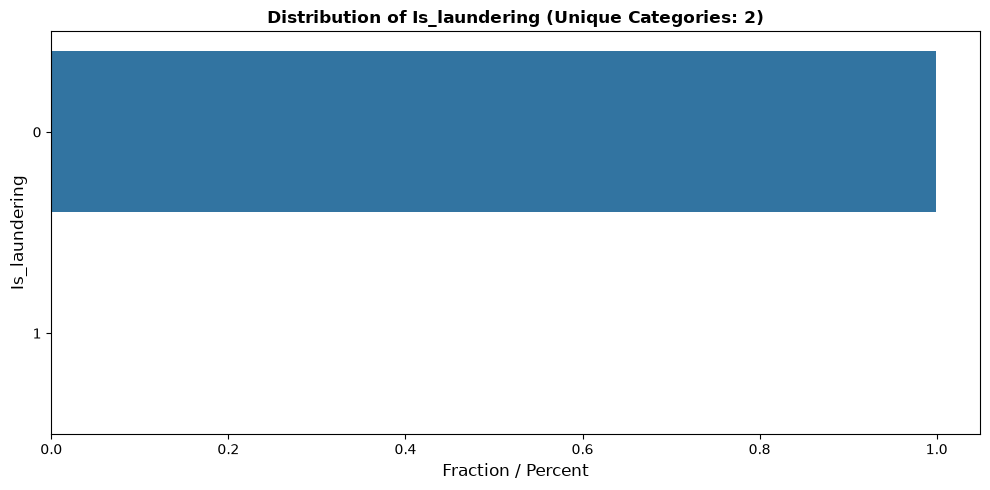

--- Variable: Laundering_type (n_uniques = 28) ---
Laundering_type
Normal_Small_Fan_Out      0.365889
Normal_Fan_Out            0.242215
Normal_Fan_In             0.221391
Normal_Group              0.055588
Normal_Cash_Withdrawal    0.032092
Normal_Cash_Deposits      0.023546
Normal_Periodical         0.022149
Normal_Plus_Mutual        0.016312
Normal_Mutual             0.013186
Normal_Foward             0.004422
Normal_single_large       0.002172
Structuring               0.000197
Cash_Withdrawal           0.000140
Deposit-Send              0.000099
Smurfing                  0.000098
Layered_Fan_In            0.000069
Layered_Fan_Out           0.000056
Stacked Bipartite         0.000053
Behavioural_Change_1      0.000041
Bipartite                 0.000040
Cycle                     0.000040
Fan_In                    0.000038
Gather-Scatter            0.000037
Behavioural_Change_2      0.000036
Scatter-Gather            0.000036
Single_large              0.000026
Fan_Out                

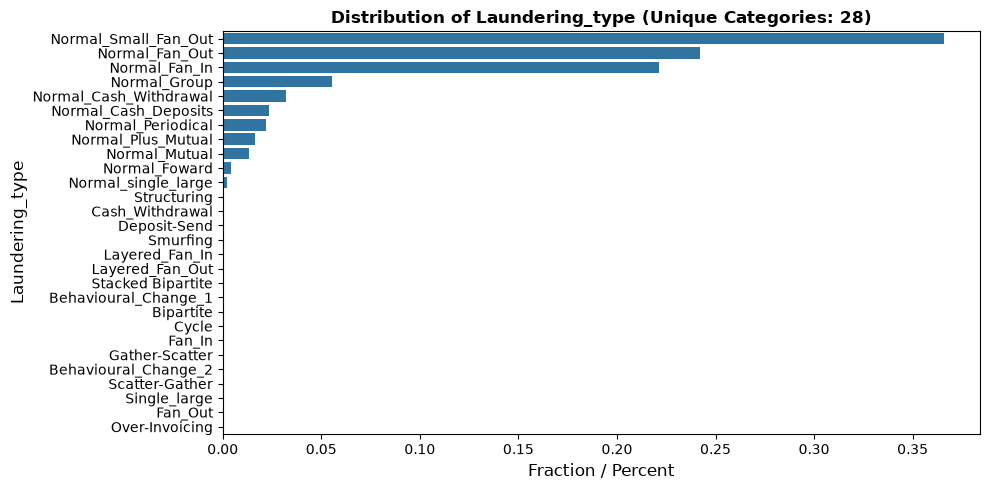

In [ ]:
def UVA_category(data, var_group):
    '''
    Univariate_Analysis_categorical
    - Prints value counts cleanly in the console.
    - Plots a clean, large horizontal bar chart for each variable.
    '''
    for i in var_group:
        norm_count = data[i].value_counts(normalize=True)
        n_uni = data[i].nunique()

        # Τυπώνουμε τα value counts καθαρά στο terminal αντί για τον τίτλο
        print(f"--- Variable: {i} (n_uniques = {n_uni}) ---")
        print(norm_count)
        print("-" * 40)

        # Δημιουργία ξεχωριστής εικόνας
        plt.figure(figsize=(10, 5), dpi=100)
        
        sns.barplot(x=norm_count.values, y=norm_count.index, order=norm_count.index, orient='h')
        
        plt.xlabel('Fraction / Percent', fontsize=12)
        plt.ylabel(i, fontsize=12)
        plt.title(f'Distribution of {i} (Unique Categories: {n_uni})', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.show()

# Εκτέλεση
UVA_category(df, ['Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'Is_laundering', 'Laundering_type'])

The Is_laundering column is quite imbalanced.

# Bivariate analysis

<Figure size 1000x600 with 0 Axes>

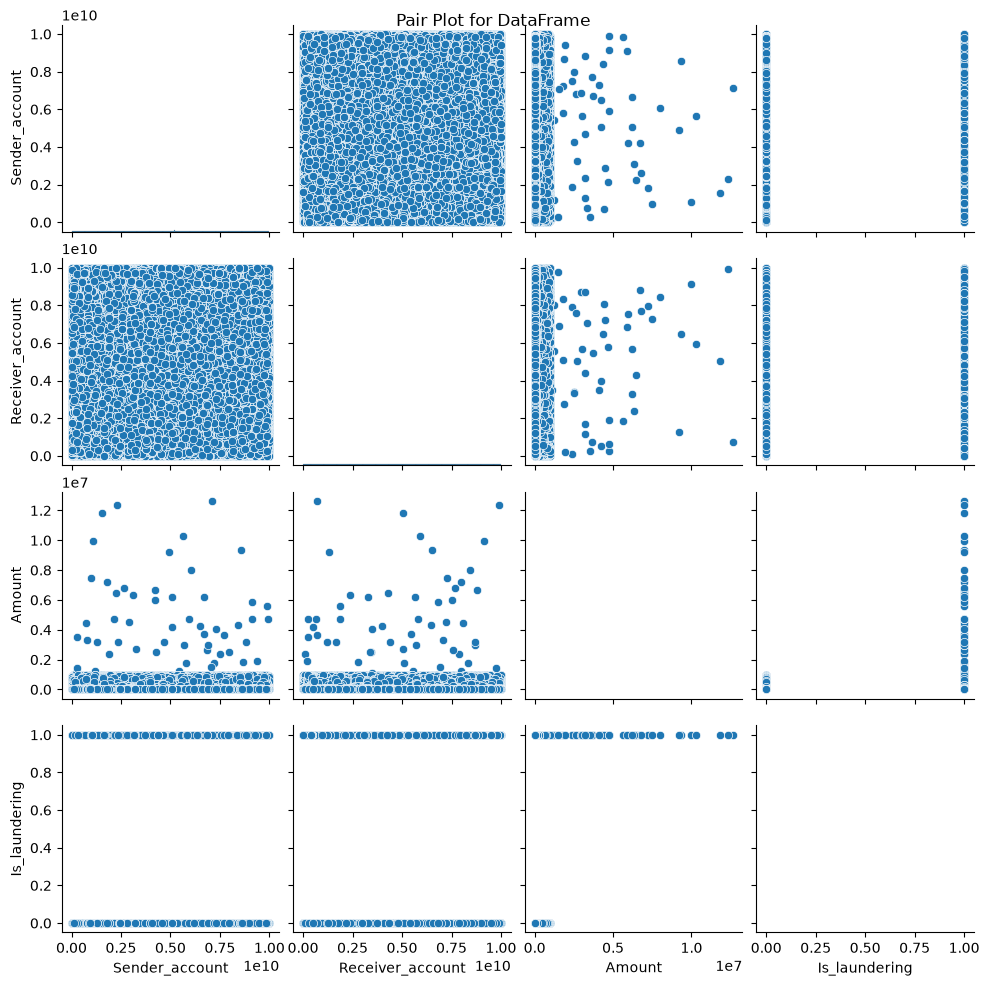

In [ ]:
# using pairplot
plt.figure(figsize=(10, 6))

sns.pairplot(df)

plt.suptitle('Pair Plot for DataFrame')
plt.show()

Skipping 'Time' because it's not a numeric variable (violin plots require numeric Y).
Skipping 'Date' because it's not a numeric variable (violin plots require numeric Y).


/tmp/ipykernel_224586/307429606.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Is_laundering", y=i, data=df, palette="Set2", alpha=0.7)


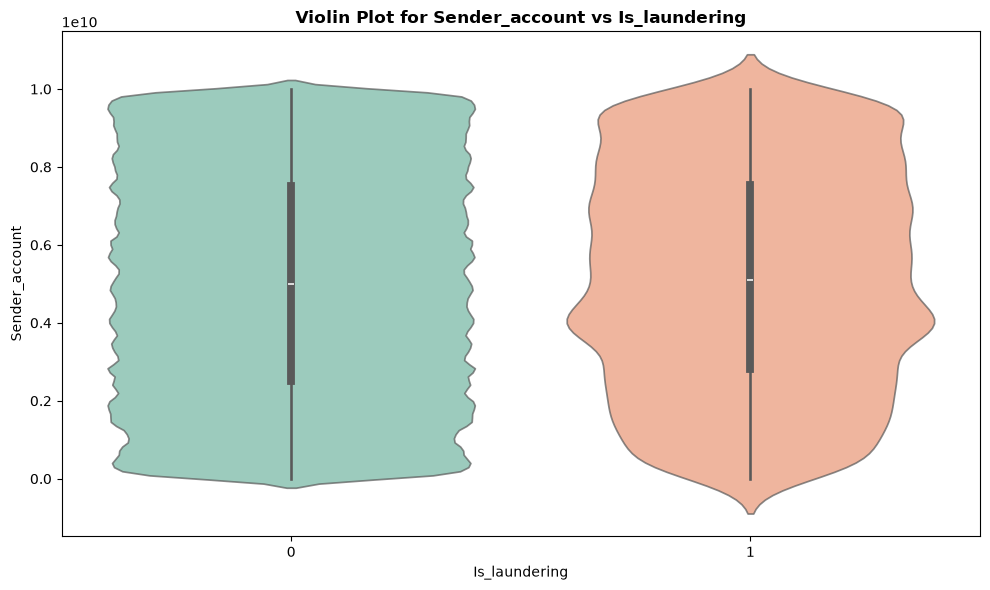

/tmp/ipykernel_224586/307429606.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Is_laundering", y=i, data=df, palette="Set2", alpha=0.7)


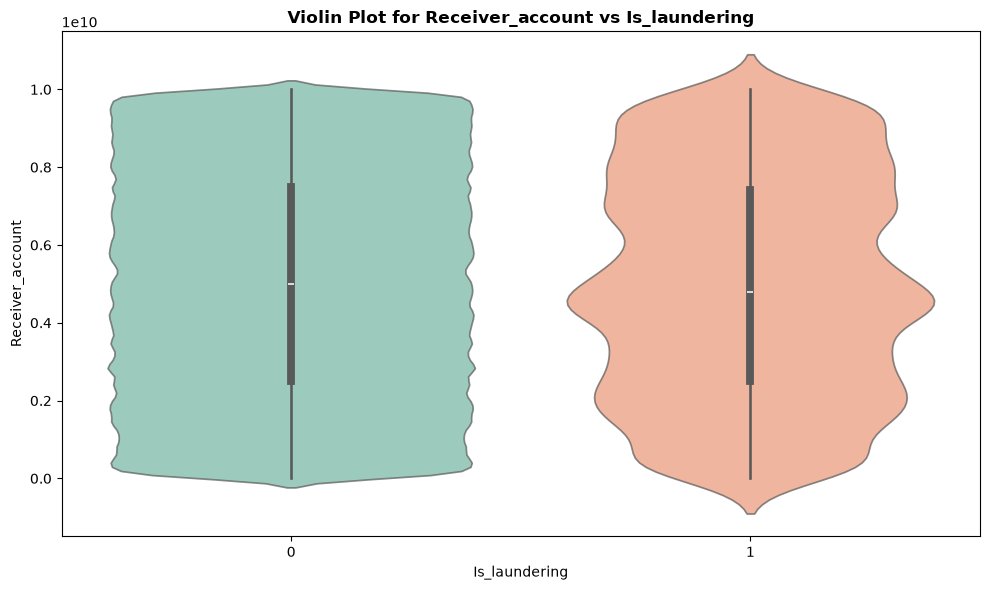

/tmp/ipykernel_224586/307429606.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Is_laundering", y=i, data=df, palette="Set2", alpha=0.7)


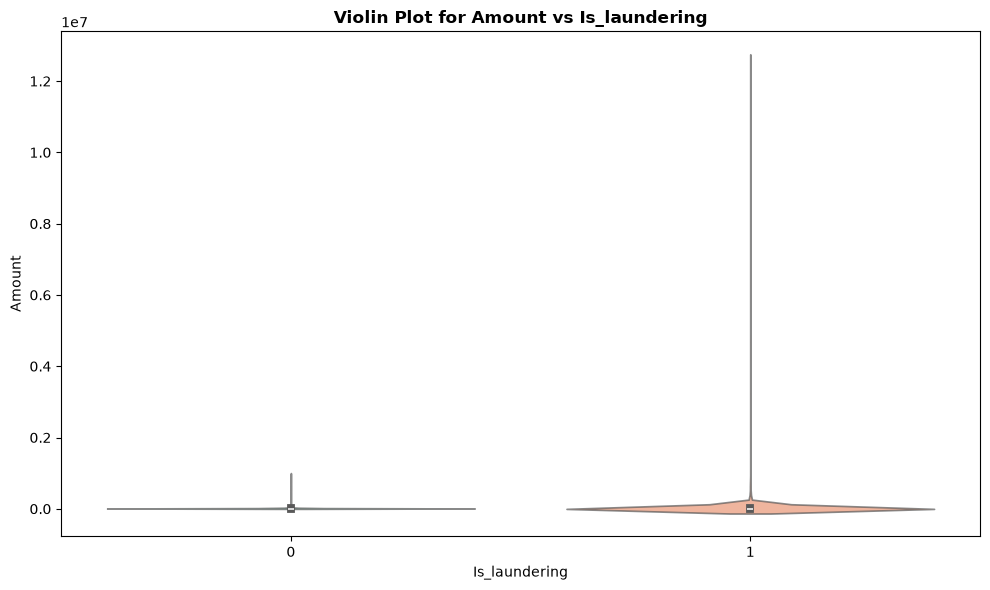

Skipping 'Payment_currency' because it's not a numeric variable (violin plots require numeric Y).
Skipping 'Received_currency' because it's not a numeric variable (violin plots require numeric Y).
Skipping 'Sender_bank_location' because it's not a numeric variable (violin plots require numeric Y).
Skipping 'Receiver_bank_location' because it's not a numeric variable (violin plots require numeric Y).
Skipping 'Payment_type' because it's not a numeric variable (violin plots require numeric Y).
Skipping 'Laundering_type' because it's not a numeric variable (violin plots require numeric Y).


In [ ]:
# Violin plot to check the relationship between variables and Is_laundering
columns = list(df.columns)

# Ελέγχουμε αν υπάρχει η στήλη 'cost' πριν προσπαθήσουμε να την αφαιρέσουμε
if 'cost' in columns:
    columns.remove('cost')

if 'Is_laundering' in columns:
    columns.remove('Is_laundering')

for i in columns:
    if pd.api.types.is_numeric_dtype(df[i]):
        plt.figure(figsize=(10, 6))
        
        # Διορθωμένα x, y και αφαίρεση του δύσκολού palette για να το διαχειριστεί αυτόματα το seaborn
        sns.violinplot(x="Is_laundering", y=i, data=df, palette="Set2", alpha=0.7)

        plt.title(f'Violin Plot for {i} vs Is_laundering', fontsize=12, fontweight='bold')
        plt.xlabel('Is_laundering', fontsize=10)
        plt.ylabel(i, fontsize=10)
        
        plt.tight_layout()
        plt.show()
    else:
        print(f"Skipping '{i}' because it's not a numeric variable (violin plots require numeric Y).")

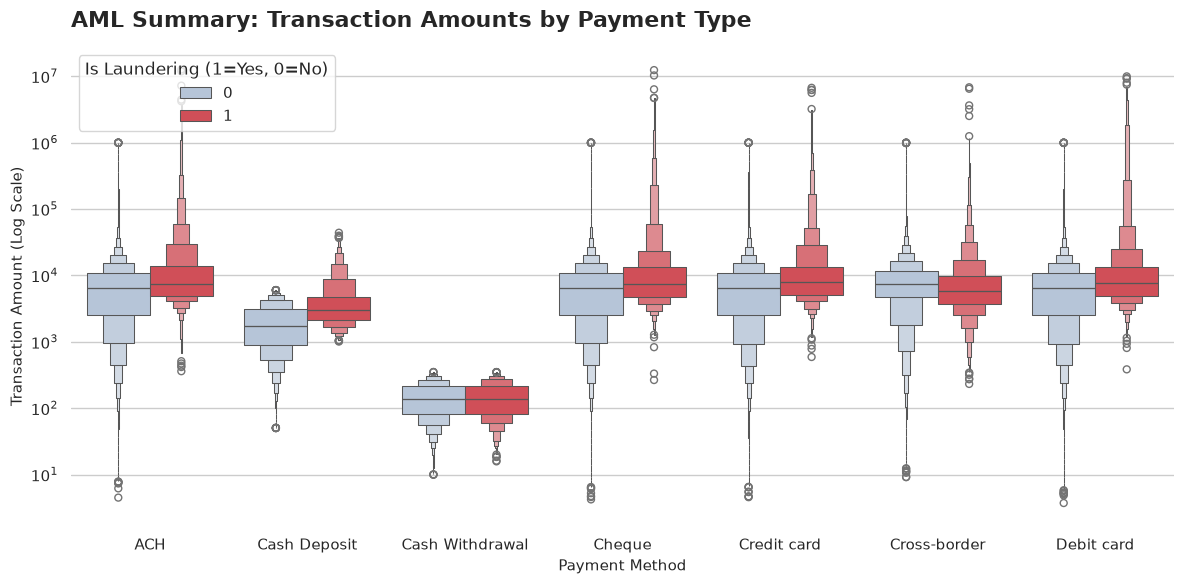

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 3. Boxenplot using your exact schema
ax = sns.boxenplot(
    data=df, 
    x='Payment_type',
    y='Amount', 
    hue='Is_laundering',   
    palette={0: "lightsteelblue", 1: "#E63946"} # Blue for Normal, Red for Laundering
)

# 4. Clean up layout
ax.set_yscale('log') # Log scale handles massive outliers gracefully
plt.title("AML Summary: Transaction Amounts by Payment Type", fontsize=16, fontweight='bold', loc='left', pad=15)
plt.ylabel("Transaction Amount (Log Scale)", fontsize=11)
plt.xlabel("Payment Method", fontsize=11)

# Clean legend and borders
plt.legend(title="Is Laundering (1=Yes, 0=No)", frameon=True, facecolor='white')
sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.show()

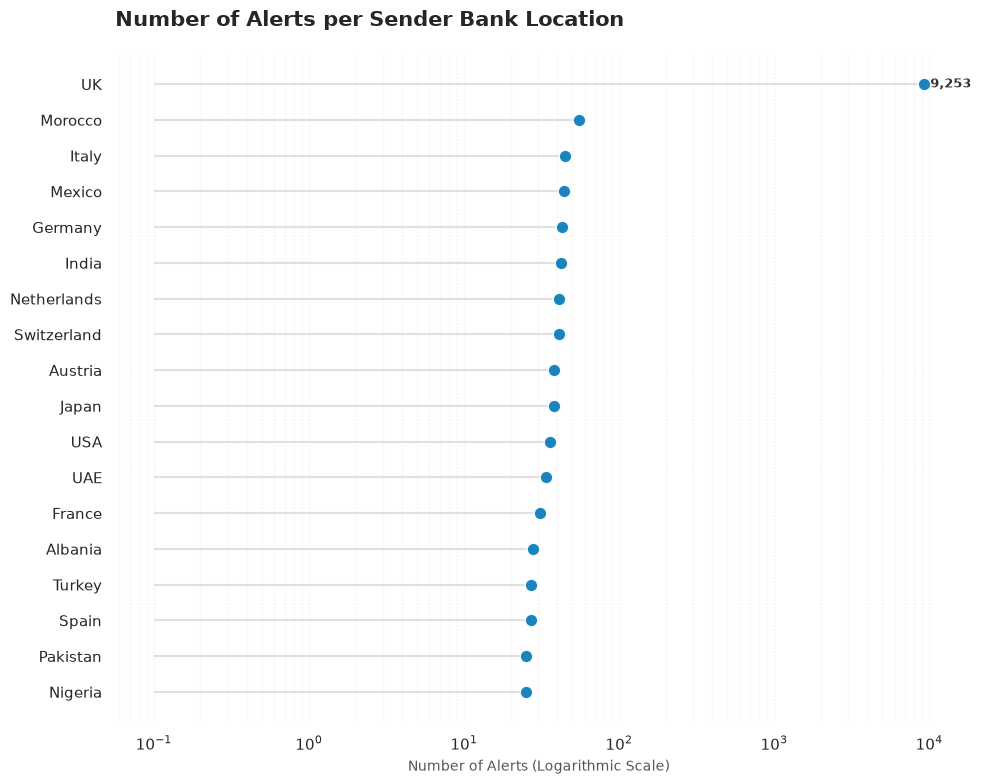

In [ ]:
# 1. Prepare and Sort Data (Sorting is key for readability)
alerts = df.groupby('Sender_bank_location')['Is_laundering'].sum().sort_values()

# 2. Setup Figure
plt.figure(figsize=(10, 8), facecolor='white')
sns.set_style("white")

# 3. Create Lollipop Chart
# The 'stem'
plt.hlines(y=alerts.index, xmin=0.1, xmax=alerts.values, color='lightgray', alpha=0.7, lw=1.5)
# The 'marker'
plt.plot(alerts.values, alerts.index, "o", markersize=9, color='#0077b6', markeredgecolor='white', alpha=0.9)

# 4. The "Magic" Fix: Logarithmic Scale
# This handles the 0-100 and 8000+ gap perfectly in one view
plt.xscale('log')

# 5. Aesthetics & Labels
plt.title("Number of Alerts per Sender Bank Location", loc='left', fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Number of Alerts (Logarithmic Scale)", fontsize=10, color='#555555')
plt.ylabel("")

# Add subtle grid lines for the log scale
plt.grid(axis='x', which='both', linestyle=':', alpha=0.3)
sns.despine(left=True, bottom=True)

# Add data labels for the high-value outliers specifically
for i, v in enumerate(alerts.values): 
    if v > 1000: # Only label the big ones to keep it clean
        plt.text(v + (v*0.1), i, f'{v:,}', va='center', fontsize=9, fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

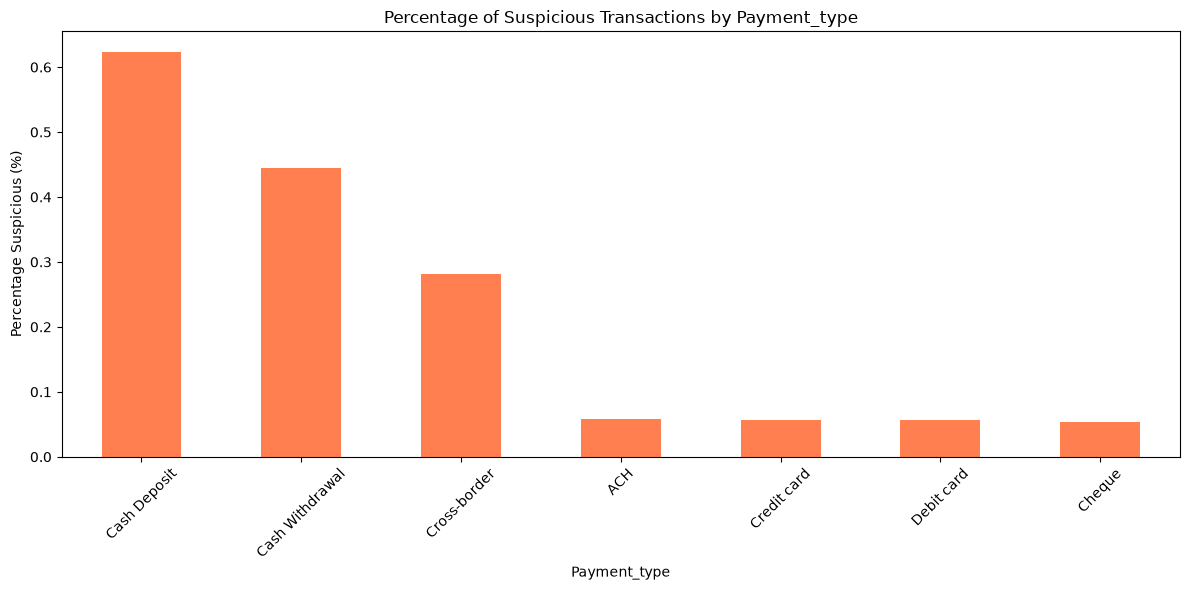

In [ ]:
# Calculate value counts and percentages for a categorical column, e.g., 'Payment Type'
cat_col = 'Payment_type'  

# Create a crosstab
cross_tab = pd.crosstab(df[cat_col], df['Is_laundering'], normalize='index') * 100
cross_tab = cross_tab.sort_values(by=1, ascending=False)  # Sort by % of suspicious

# Plot
plt.figure(figsize=(12, 6))
cross_tab[1].plot(kind='bar', color='coral') # Plot only the % suspicious
plt.title(f'Percentage of Suspicious Transactions by {cat_col}')
plt.ylabel('Percentage Suspicious (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

So the most suspicious payment type is the cash deposit.

# Feature transformation/encoding.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# from imblearn.over_sampling import RandomOverSampler

X = df.drop(columns=["Is_laundering", "Sender_account", "Receiver_account"])
y = df["Is_laundering"] # highly imbalanced

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Preprocessing
categorical_cols = X.select_dtypes(include="object").columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

/tmp/ipykernel_131423/2359730354.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns


In [ ]:
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", StandardScaler(), numeric_cols)
])

# Transform data
x_train_final = preprocessor.fit_transform(X_train)
x_test_final = preprocessor.transform(X_test)

In [14]:
x_train_final= x_train_final.drop(columns=['Time'])
from imblearn.over_sampling import SMOTE

# 2. Κάνουμε One-Hot Encoding σε ΟΛΕΣ τις υπόλοιπες κατηγορικές στήλες
X_encoded = pd.get_dummies(x_train_final)

# 3. Τώρα το X_encoded έχει μόνο 0 και 1 (αριθμούς), οπότε το SMOTE θα δουλέψει
smote = SMOTE(sampling_strategy='minority', random_state=42)
x_train_final, y_train = smote.fit_resample(X_encoded, y_train)

AttributeError: 'csr_matrix' object has no attribute 'drop'

In [13]:
print(X_train.select_dtypes(include=['object', 'category']).columns)

Index(['Time', 'Payment_currency', 'Received_currency', 'Sender_bank_location',
       'Receiver_bank_location', 'Payment_type', 'Laundering_type'],
      dtype='str')


/tmp/ipykernel_131423/2804409644.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X_train.select_dtypes(include=['object', 'category']).columns)


In [ ]:

smote = SMOTE(sampling_strategy='minority', random_state=42)
x_train_final, y_train = smote.fit_resample(X_train, y_train)

ValueError: could not convert string to float: '23:02:27'

In [ ]:
import mlflow

tracking_uri = "http://localhost:5000"
mlflow.set_tracking_uri(tracking_uri)

mlflow.set_experiment("Anti money laundering experiment")


2026/09/09 12:55:20 INFO mlflow.tracking.fluent: Experiment with name 'Anti money laundering experiment' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1788947720020, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1788947720020, lifecycle_stage='active', name='Anti money laundering experiment', tags={}, trace_location=None, workspace='default'>

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models i 'll use to classify the data

models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boost": GradientBoostingClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(), 
    'lightgbm':LGBMClassifier()
}

In [ ]:
from sklearn.linear_model import SGDClassifier

# Enable autologging for scikit-learn
mlflow.sklearn.autolog()

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(x_train_final, y_train)

2026/09/09 12:55:37 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'e14c88849a6441e0ae04e49ad86a484b', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/09/09 12:55:37 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: Unable to allocate 4.78 TiB for an array with shape (7603881, 86419) and data type float64
2026/09/09 12:55:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/home/charis/Desktop/Projects/Anti-Money-Laundering-Transaction/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py

🏃 View run omniscient-fly-888 at: http://localhost:5000/#/experiments/1/runs/e14c88849a6441e0ae04e49ad86a484b
🧪 View experiment at: http://localhost:5000/#/experiments/1


,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",42
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i